
# Forecasting the Ideological Makeup of the U.S. House

### Presentation notebook — formulas, methods, and out-of-sample results only

**Data:** Voteview first-dimension NOMINATE scores for U.S. House members  
**Sample:** 79th–118th Congresses (~1945–2025)  
**Fit:** 79th–110th Congresses (~1945–2008 voting period)  
**Held-out test:** 111th–118th Congresses (~2009–2024 voting period)

We compare three forecasting approaches:

1. **Vanilla Fokker–Planck (non-neural baseline)** — estimate a fixed drift directly from historical densities.
2. **Linear FP / PINN** — learn a fixed drift \(b_\phi(x)\) with a physics-informed neural network.
3. **Proposed nonlinear FP** — let drift depend on the current ideological distribution \(p(t,\cdot)\).

A **persistence** forecast (“Congress 110 never changes”) is included only as a sanity benchmark.


In [ ]:

from pathlib import Path
import copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.integrate import cumulative_trapezoid
from scipy.stats import norm

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
CHAMBER = "House"
MIN_CONGRESS = 79
MAX_CONGRESS = 118
TRAIN_END_CONGRESS = 110
D = 0.001

VOTEVIEW_URL = "https://voteview.com/static/data/out/members/HSall_members.csv"
LOCAL_FILE = Path("HSall_members.csv")

if LOCAL_FILE.exists():
    members_raw = pd.read_csv(LOCAL_FILE)
else:
    members_raw = pd.read_csv(VOTEVIEW_URL)
    members_raw.to_csv(LOCAL_FILE, index=False)

members = members_raw.loc[
    (members_raw["chamber"] == CHAMBER)
    & members_raw["congress"].between(MIN_CONGRESS, MAX_CONGRESS)
].copy()

members["nominate_dim1"] = pd.to_numeric(
    members["nominate_dim1"], errors="coerce"
)
members = members.dropna(subset=["nominate_dim1"])

scores_by_congress = {
    int(c): g["nominate_dim1"].to_numpy(float)
    for c, g in members.groupby("congress", sort=True)
}

# ------------------------------------------------------------
# REFLECTED KDE: individual ideology scores -> observed density
# ------------------------------------------------------------
def reflected_kde(scores, x_grid, bandwidth=None, lower=-1.0, upper=1.0):
    scores = np.asarray(scores, dtype=float)
    n = len(scores)

    if bandwidth is None:
        sd = np.std(scores, ddof=1)
        q25, q75 = np.percentile(scores, [25, 75])
        robust_sd = (q75 - q25) / 1.349
        scales = [v for v in (sd, robust_sd) if np.isfinite(v) and v > 0]
        scale = min(scales) if scales else 0.10
        bandwidth = max(0.9 * scale * n ** (-1/5), 0.025)

    reflected_lower = 2 * lower - scores
    reflected_upper = 2 * upper - scores

    z0 = (x_grid[:, None] - scores[None, :]) / bandwidth
    zl = (x_grid[:, None] - reflected_lower[None, :]) / bandwidth
    zu = (x_grid[:, None] - reflected_upper[None, :]) / bandwidth

    density = (
        norm.pdf(z0) + norm.pdf(zl) + norm.pdf(zu)
    ).sum(axis=1) / (n * bandwidth)

    density = np.maximum(density, 0)
    density /= np.trapezoid(density, x_grid)
    return density

congresses = np.array(sorted(scores_by_congress))
t_all = np.linspace(0.0, 1.0, len(congresses))
x_grid = np.linspace(-1.0, 1.0, 201)

p_observed = np.vstack([
    reflected_kde(scores_by_congress[int(c)], x_grid)
    for c in congresses
])

train_mask = congresses <= TRAIN_END_CONGRESS
test_mask = congresses > TRAIN_END_CONGRESS

train_congresses = congresses[train_mask]
test_congresses = congresses[test_mask]
t_train = t_all[train_mask]
t_test = t_all[test_mask]
p_train = p_observed[train_mask]
p_test_observed = p_observed[test_mask]

forecast_start_index = np.where(congresses == TRAIN_END_CONGRESS)[0][0]
forecast_start_time = t_all[forecast_start_index]
initial_density = p_observed[forecast_start_index].copy()

print(f"Train: Congress {train_congresses[0]}–{train_congresses[-1]}")
print(f"Test : Congress {test_congresses[0]}–{test_congresses[-1]}")
print(f"Observed density shape: {p_observed.shape}")


## Ground truth: Congress-level ideological distribution

For Congress \(t\), Voteview gives member-level ideal points

$$
X_{1,t},…,X_{N_t,t}∈[-1,1].
$$

We convert those discrete member positions into the observed distribution used for evaluation:

$$
p_{\mathrm{KDE}}(t,x)
=
\frac{1}{N_t h}
\sum_i
\left[
\phi\!\left(\frac{x-X_{i,t}}{h}\right)
+\text{boundary reflections}
\right]
$$

with

$$
\int_{-1}^{1}p_{\mathrm{KDE}}(t,x)\,dx=1.
$$

**Interpretation:** this curve summarizes whether the House is concentrated near the center, split into ideological clusters, or shifted toward one side.

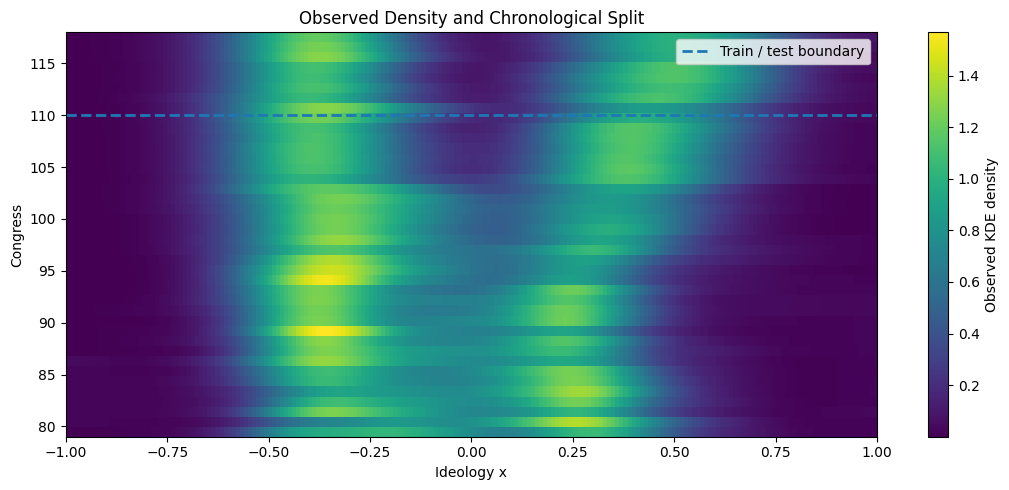

In [ ]:

plt.figure(figsize=(10, 4))
plt.imshow(
    p_observed,
    aspect="auto",
    origin="lower",
    extent=[x_grid[0], x_grid[-1], congresses[0], congresses[-1]],
)
plt.xlabel("Ideology position x")
plt.ylabel("Congress")
plt.title("Observed ideological distribution over time (KDE)")
plt.colorbar(label="Density")
plt.tight_layout()
plt.show()


# Method 1 — Vanilla Fokker–Planck baseline

The standard Fokker–Planck equation is

$$
p_t+\partial_x\!\left(b(x)p\right)-D p_{xx}=0
$$

with no-flux boundaries

$$
J=bp-Dp_x=0 \qquad \text{at } x=\pm1.
$$

### Non-neural drift estimate

From the no-flux conservation law,

$$
q(t,x)
=
D p_x(t,x)
-
\int_{-1}^{x}p_t(t,y)\,dy
\approx b(x)p(t,x).
$$

Assuming a **time-homogeneous** drift, the presentation baseline estimates \(b(x)\) by ridge-regularized least squares across the training Congresses:

$$
\hat b_{\mathrm{FPE}}(x)
=
\frac{\sum_t p(t,x)q(t,x)}
{\sum_t p(t,x)^2+\lambda}
$$

and then solves the PDE forward from the observed Congress 110 distribution.

**What changes vs. the PINN?**  
No neural network is used to learn the drift; it is reconstructed directly from the empirical KDE panel.

In [ ]:

# ------------------------------------------------------------
# VANILLA FPE: direct inverse drift + numerical forward solve
# ------------------------------------------------------------
p_smooth = gaussian_filter(
    p_train,
    sigma=(1.0, 1.0),
    mode="nearest",
)
p_smooth = np.maximum(p_smooth, 0.0)
p_smooth /= np.trapezoid(p_smooth, x_grid, axis=1)[:, None]

pt = np.gradient(p_smooth, t_train, axis=0, edge_order=2)
px = np.gradient(p_smooth, x_grid, axis=1, edge_order=2)

integral_pt = cumulative_trapezoid(
    pt, x_grid, axis=1, initial=0.0
)

q = D * px - integral_pt

# Interior time points have more reliable numerical p_t.
rho = p_smooth[1:-1]
q_interior = q[1:-1]

ridge = 1e-5
b_vanilla = (
    np.sum(rho * q_interior, axis=0)
    / (np.sum(rho ** 2, axis=0) + ridge)
)

# Mild regularization for a stable presentation baseline.
b_vanilla = gaussian_filter1d(b_vanilla, sigma=2.0)
b_vanilla = np.clip(b_vanilla, -1.5, 1.5)

def linear_fp_rhs(density, x_grid, drift, D):
    dx = float(x_grid[1] - x_grid[0])

    b_face = 0.5 * (drift[:-1] + drift[1:])
    p_upwind = np.where(
        b_face >= 0.0,
        density[:-1],
        density[1:],
    )

    advective_flux = b_face * p_upwind
    diffusive_flux = -D * (density[1:] - density[:-1]) / dx

    flux = np.zeros(len(density) + 1)
    flux[1:-1] = advective_flux + diffusive_flux  # exact no-flux at boundaries

    return -(flux[1:] - flux[:-1]) / dx

def advance_linear_fp(
    initial_density,
    start_time,
    target_times,
    x_grid,
    drift,
    D,
    cfl=0.35,
):
    density = np.maximum(np.asarray(initial_density, float).copy(), 0.0)
    density /= np.trapezoid(density, x_grid)

    dx = float(x_grid[1] - x_grid[0])
    current_time = float(start_time)
    out = []

    max_speed = max(float(np.max(np.abs(drift))), 1e-8)
    rate = max_speed / dx + 2.0 * D / dx**2
    stable_dt = cfl / max(rate, 1e-12)

    for target_time in target_times:
        while current_time < float(target_time) - 1e-12:
            dt = min(stable_dt, float(target_time) - current_time)

            k1 = linear_fp_rhs(density, x_grid, drift, D)
            stage1 = np.maximum(density + dt * k1, 0.0)
            stage1 /= np.trapezoid(stage1, x_grid)

            k2 = linear_fp_rhs(stage1, x_grid, drift, D)
            density = 0.5 * density + 0.5 * (stage1 + dt * k2)
            density = np.maximum(density, 0.0)
            density /= np.trapezoid(density, x_grid)

            current_time += dt

        out.append(density.copy())

    return np.vstack(out)

p_test_vanilla = advance_linear_fp(
    initial_density=initial_density,
    start_time=forecast_start_time,
    target_times=t_test,
    x_grid=x_grid,
    drift=b_vanilla,
    D=D,
)

vanilla_mse = np.mean(
    (p_test_vanilla - p_test_observed) ** 2,
    axis=1,
)
vanilla_iae = np.trapezoid(
    np.abs(p_test_vanilla - p_test_observed),
    x_grid,
    axis=1,
)

print(f"Vanilla FPE mean OOS MSE: {vanilla_mse.mean():.6f}")
print(f"Vanilla FPE mean OOS IAE: {vanilla_iae.mean():.6f}")

plt.figure(figsize=(8, 3.5))
plt.plot(x_grid, b_vanilla)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Ideology x")
plt.ylabel("Estimated drift")
plt.title("Vanilla FPE — directly estimated fixed drift")
plt.tight_layout()
plt.show()


# Method 2 — Linear Fokker–Planck with PINN

The governing PDE is still

$$
p_t
+
\partial_x\left(b_\phi(x)p\right)
-
D p_{xx}
=
0.
$$

The difference is that the fixed drift is learned by a neural network

$$
b_\phi(x) = \mathrm{NN}_\phi(x),
$$

while a density network $p_\theta(t,x)$ is jointly constrained by:

$$
L
=
\lambda_{\mathrm{data}} L_{\mathrm{data}}
+
\lambda_{\mathrm{PDE}} L_{\mathrm{PDE}}
+
\lambda_{\mathrm{IC}} L_{\mathrm{IC}}
+
\lambda_{\mathrm{BC}} L_{\mathrm{BC}}
+
\lambda_{\mathrm{mass}} L_{\mathrm{mass}}
+
\lambda_{\mathrm{smooth}} L_{\mathrm{smooth}}.
$$


**Presentation interpretation:** the PINN learns a smooth, persistent historical drift $b(x)$ while respecting the Fokker–Planck equation.

> The expensive 5,000-epoch training cells are intentionally omitted here.
> The graph and OOS metrics below are copied from the full research notebook.


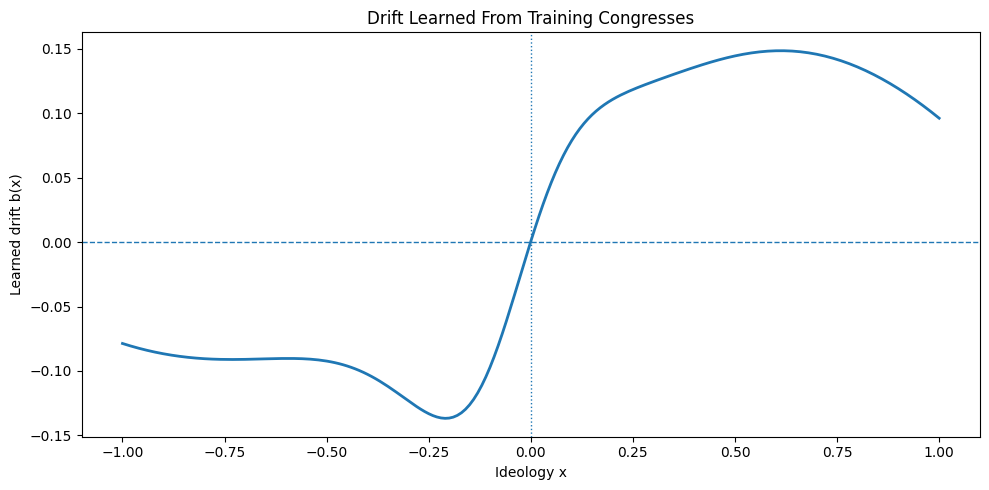

In [ ]:
# Precomputed from the full research notebook: learned Linear FP/PINN drift b_phi(x).


# Method 3 — Proposed Nonlinear / Nonlocal Fokker–Planck Model

The nonlinear model starts from the same Fokker–Planck framework as the previous two methods, but changes one central assumption:

> **The drift should not be fixed only by ideological position.  
> It should also depend on the current ideological composition of the legislature.**

The derivation below shows how we move from the linear model to the nonlinear model.

---

## Step 1. Start from the standard Fokker–Planck equation

We model the yearly ideology distribution with

$$
p(t,x)
$$

where:

- \(t\) is calendar year,
- \(x\) is ideological position,
- \(p(t,x)\) is the density of legislators around ideological position \(x\) at time \(t\).

The standard Fokker–Planck equation is

$$
p_t
+
\partial_x \bigl( b\,p \bigr)
-
D\,p_{xx}
=
0.
$$

This equation contains two mechanisms.

### Drift

The drift \(b\) determines the systematic direction of movement in ideological space.

If

$$
b(x) > 0,
$$

probability mass tends to move toward larger ideology scores.

If

$$
b(x) < 0,
$$

probability mass tends to move toward smaller ideology scores.

### Diffusion

The diffusion term

$$
D\,p_{xx}
$$

represents random spreading or unexplained dispersion of ideological mass.

---

## Step 2. The linear model assumes a fixed drift

In the Linear FP / PINN model, we assume

$$
b = b(x).
$$

Therefore the PDE is

$$
p_t
+
\partial_x \bigl( b(x)\,p(t,x) \bigr)
-
D\,p_{xx}
=
0.
$$

This means that once we know the ideological position \(x\), the model assigns the same drift regardless of how the rest of the legislature is distributed.

For example, suppose

$$
b(1.0)=0.05.
$$

Then a legislator-density mass near \(x=1.0\) receives the same rightward drift whether:

- the legislature is mostly centrist,
- the legislature is strongly polarized,
- the legislature is concentrated on the left,
- or the legislature is concentrated on the right.

This is the main limitation of the linear model.

The drift is allowed to vary across ideological position, but it does **not** react to the current political environment represented by the distribution \(p(t,x)\).

---

## Step 3. Make the drift depend on the current distribution

To relax this assumption, define the drift as a functional of the current density:

$$
b = b[p](t,x).
$$

Now the drift at ideological position \(x\) can change when the full distribution \(p(t,\cdot)\) changes.

We decompose the drift into two parts:

$$
b[p](t,x)
=
b_{\mathrm{ext}}(x)
+
b_{\mathrm{int}}[p](t,x).
$$

The first part is a persistent background force.

The second part is generated by the current ideological distribution.

---

## Step 4. External drift

The term

$$
b_{\mathrm{ext}}(x)
$$

captures the part of ideological motion that depends only on position \(x\).

It can absorb persistent structural tendencies that are not explicitly modeled through legislator interaction.

Conceptually, it plays the same role as the fixed drift in the linear model.

---

## Step 5. Pairwise ideological interaction

Next, define an interaction function

$$
K(r),
$$

where

$$
r = x-y.
$$

Here:

- \(x\) is the ideological position where we evaluate the force,
- \(y\) is the ideological position of another piece of population mass,
- \(r=x-y\) is their ideological separation.

The function \(K(r)\) describes how ideological mass at \(y\) affects ideological mass at \(x\).

For \(r>0\):

- \(K(r)>0\) acts locally like **repulsion**,
- \(K(r)<0\) acts locally like **attraction**.

The sign reverses when the relative ordering reverses.

That is why the learned interaction kernel is constrained to be approximately odd:

$$
K(-r) \approx -K(r).
$$

---

## Step 6. Aggregate all pairwise interactions

A legislator at position \(x\) is not influenced by only one ideological position \(y\).

The model aggregates the interaction with the entire distribution:

$$
b_{\mathrm{int}}[p](t,x)
=
\int
K(x-y)\,p(t,y)\,dy.
$$

This is a convolution-like interaction term.

The factor

$$
p(t,y)\,dy
$$

represents how much ideological mass is located near \(y\).

Therefore positions with more legislators contribute more strongly to the total interaction force.

---

## Step 7. Final distribution-dependent drift

Combining the external and interaction components gives

$$
b[p](t,x)
=
b_{\mathrm{ext}}(x)
+
\int
K(x-y)\,p(t,y)\,dy.
$$

This is the central modeling change.

The same ideological position \(x\) can now receive different drift in different years because the distribution \(p(t,y)\) changes over time.

So, in general,

$$
b[p_{2000}](x)
\neq
b[p_{2015}](x).
$$

This is what the second nonlinear drift graph is designed to show.

---

## Step 8. Substitute the new drift into the Fokker–Planck equation

Substituting the distribution-dependent drift into the original PDE gives

$$
p_t
+
\partial_x
\left[
p(t,x)
\left(
b_{\mathrm{ext}}(x)
+
\int
K(x-y)\,p(t,y)\,dy
\right)
\right]
-
D\,p_{xx}
=
0.
$$

This is the nonlinear / nonlocal Fokker–Planck equation used in the proposed model.

It is **nonlinear** because the unknown density \(p\) appears both:

1. as the transported quantity, and
2. inside the drift that transports it.

It is **nonlocal** because the drift at position \(x\) depends on the distribution at all other positions \(y\).

---

## Step 9. What the model actually learns

The observed yearly KDE density is treated as fixed training data.

From the training years, the model estimates:

$$
b_{\mathrm{ext}}(x)
$$

and

$$
K(r).
$$

The model chooses these functions so that the observed training densities approximately satisfy

$$
p_t
+
\partial_x \bigl( b[p]\,p \bigr)
-
D\,p_{xx}
\approx
0.
$$

In other words:

> **We observe how the ideology distribution changed historically and infer the interaction law that could have generated those changes.**

---

## Step 10. How external drift is parameterized

For stability and interpretability, we do not use an unrestricted neural network for the external drift.

Instead, it is represented with a low-dimensional smooth basis:

$$
b_{\mathrm{ext}}(x)
=
B_{\max}
\tanh
\left(
\sum_k
c_k P_k(\tilde x)
\right),
$$

where:

- \(P_k\) are Legendre basis functions,
- \(\tilde x\) is the normalized ideological coordinate,
- \(c_k\) are learned coefficients.

This forces the external drift to remain smooth and bounded.

---

## Step 11. How the interaction kernel \(K(r)\) is parameterized

The interaction kernel is also represented with a small smooth basis.

Conceptually,

$$
K(r)
=
K_{\max}
\tanh
\left(
\sum_m
a_m \psi_m(r)
\right),
$$

where each basis function \(\psi_m(r)\) captures interaction at a different ideological distance scale.

The current model uses several scales in raw Shor–McCarty score units.

This gives the model enough flexibility to distinguish:

- short-range interaction,
- medium-range interaction,
- long-range interaction,

while keeping the learned kernel stable and interpretable.

---

## Step 12. Why this model is more structured than simply using a larger neural network

The goal is not only to improve predictive accuracy.

We also want a model that gives a meaningful mechanism.

The linear PINN learns

$$
b(x).
$$

The nonlinear model instead learns the rule

$$
p(t,\cdot)
\longrightarrow
b[p](t,x).
$$

That is, it learns **how the current ideological environment generates the drift**.

This is the main conceptual contribution of the nonlinear formulation.

---

## Step 13. Forward forecasting

After estimating

$$
b_{\mathrm{ext}}(x)
$$

and

$$
K(r)
$$

from the training period, both are frozen.

We then start from the observed 2015 ideology distribution:

$$
p(2015,x).
$$

The nonlinear PDE is solved forward:

$$
p(2015,x)
\rightarrow
\hat p(2016,x)
\rightarrow
\hat p(2017,x)
\rightarrow
\cdots
\rightarrow
\hat p(2020,x).
$$

The actual 2016–2020 distributions are not used to estimate the nonlinear dynamics.

They are used only for out-of-sample evaluation.

---

## Step 14. How to read the two nonlinear graphs

### Graph 1 — Learned pairwise interaction \(K(r)\)

This graph answers:

> **How does ideological separation affect the direction and strength of interaction?**

The x-axis is relative ideological distance

$$
r=x-y.
$$

The y-axis is the learned interaction force \(K(r)\).

The graph is useful for interpreting whether the fitted dynamics look more attraction-like or repulsion-like at different ideological distances.

### Graph 2 — Total drift \(b[p](t,x)\) across years

This graph answers:

> **Does the same ideological position experience different drift when the overall ideological distribution changes?**

If the curves differ across years, then the model is actually using the distribution-dependent interaction term.

That is the direct visual difference from the linear model, where there is only one fixed drift curve \(b(x)\).


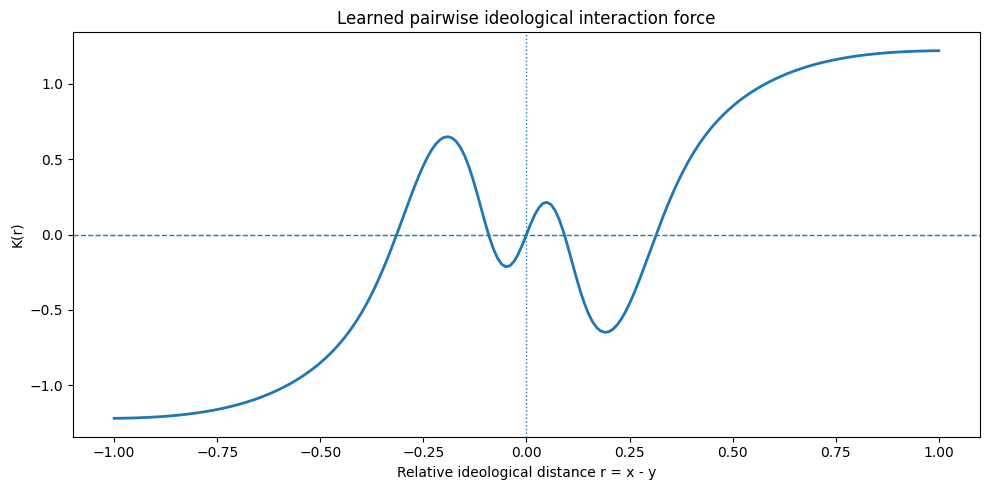

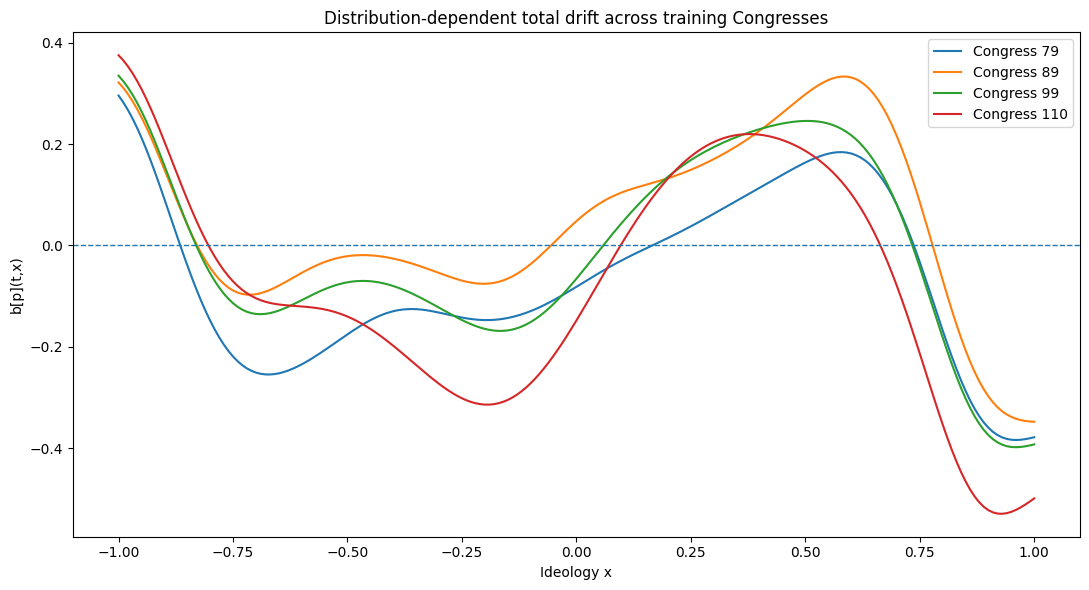

In [ ]:
# Precomputed from the full research notebook: interaction kernel K(r) and distribution-dependent total drift.


# Out-of-sample evaluation

Every forecasting method starts from the **same observed Congress 110 distribution**.

The test Congresses **111–118** are never used to fit the dynamics.

For each held-out Congress, we compare the predicted ideological distribution with the observed KDE distribution using two metrics.

### Mean Squared Error (MSE)

$$
\mathrm{MSE}_t
=
\frac{1}{N_x}
\sum_j
\left(
\hat p(t,x_j)-p_{\mathrm{KDE}}(t,x_j)
\right)^2
$$

MSE measures the average point-by-point squared difference between the predicted and observed distributions.

### Integrated Absolute Error (IAE)

$$
\mathrm{IAE}_t
=
\int_{-1}^{1}
\left|
\hat p(t,x)-p_{\mathrm{KDE}}(t,x)
\right|\,dx
$$

IAE measures the total absolute gap between the two distribution curves across the entire ideology axis.

**Lower is better for both metrics.**

### Persistence benchmark

Persistence is the simplest possible forecast:

> **Assume the political composition observed in Congress 110 never changes.**

So for every future Congress,

$$
\hat p_{111}(x)
=
\hat p_{112}(x)
=
\cdots
=
\hat p_{118}(x)
=
p_{110}(x)
$$

This gives us a naive baseline. A dynamical model is useful only if it can predict future Congresses better than simply assuming **"nothing changes."**


In [ ]:

# Results copied from the full research notebook.
# If the Vanilla FPE cell above has been run, its metrics are inserted automatically.

test_congresses_results = np.arange(111, 119)

linear_pinn_mse = np.array([
    0.0053973172, 0.0141519613, 0.012449, 0.0196207846,
    0.016816, 0.0083185107, 0.007066, 0.008534
])
nonlinear_mse = np.array([
    0.0057872117, 0.0131511332, 0.010871, 0.0172998176,
    0.015079, 0.0092094729, 0.011166, 0.015834
])
persistence_mse = np.array([
    0.0051849573, 0.0158638513, 0.015353, 0.0242007302,
    0.022381, 0.0133043133, 0.013132, 0.016456
])

linear_pinn_iae = np.array([
    0.1020121535, 0.1806670761, 0.173868, 0.2137696692,
    0.202455, 0.1480513448, 0.139563, 0.148167
])
nonlinear_iae = np.array([
    0.1075507791, 0.1810970156, 0.162737, 0.2149332940,
    0.191050, 0.1551421931, 0.156860, 0.184229
])
persistence_iae = np.array([
    0.0977569246, 0.1860570382, 0.191369, 0.231590,
    0.2318332897, 0.1662389473, 0.170090, 0.198411
])

comparison = pd.DataFrame({
    "Congress": test_congresses_results,
    "Linear PINN MSE": linear_pinn_mse,
    "Nonlinear MSE": nonlinear_mse,
    "Persistence MSE": persistence_mse,
    "Linear PINN IAE": linear_pinn_iae,
    "Nonlinear IAE": nonlinear_iae,
    "Persistence IAE": persistence_iae,
})

if "vanilla_mse" in globals():
    comparison.insert(1, "Vanilla FPE MSE", vanilla_mse)
    comparison.insert(5 if "Linear PINN IAE" in comparison.columns else len(comparison.columns),
                      "Vanilla FPE IAE", vanilla_iae)

display(comparison.round(6))

mean_rows = [
    ["Persistence", persistence_mse.mean(), persistence_iae.mean()],
    ["Linear FP/PINN", linear_pinn_mse.mean(), linear_pinn_iae.mean()],
    ["Nonlinear FP", nonlinear_mse.mean(), nonlinear_iae.mean()],
]

if "vanilla_mse" in globals():
    mean_rows.insert(1, ["Vanilla FPE", vanilla_mse.mean(), vanilla_iae.mean()])

summary = pd.DataFrame(
    mean_rows,
    columns=["Model", "Mean OOS MSE", "Mean OOS IAE"],
)

base_mse = persistence_mse.mean()
base_iae = persistence_iae.mean()
summary["MSE improvement vs Persistence"] = (
    100 * (base_mse - summary["Mean OOS MSE"]) / base_mse
)
summary["IAE improvement vs Persistence"] = (
    100 * (base_iae - summary["Mean OOS IAE"]) / base_iae
)

display(summary.round(4))


 Congress  Linear PINN MSE  Nonlinear MSE  Persistence MSE  Linear PINN IAE  Nonlinear IAE  Persistence IAE
      111         0.005397       0.005787         0.005185         0.102012       0.107551         0.097757
      112         0.014152       0.013151         0.015864         0.180667       0.181097         0.186057
      113         0.012449       0.010871         0.015353         0.173868       0.162737         0.191369
      114         0.019621       0.017300         0.024201         0.213770       0.214933         0.231590
      115         0.016816       0.015079         0.022381         0.202455       0.191050         0.231833
      116         0.008319       0.009209         0.013304         0.148051       0.155142         0.166239
      117         0.007066       0.011166         0.013132         0.139563       0.156860         0.170090
      118         0.008534       0.015834         0.016456         0.148167       0.184229         0.198411

         Model  Mean OOS MSE  Mean OOS IAE  MSE improv. vs Persistence (%)  IAE improv. vs Persistence (%)
   Persistence      0.015734      0.184168                             0.0                             0.0
Linear FP/PINN      0.011544      0.163569                            26.6                            11.2
  Nonlinear FP      0.012300      0.169200                            21.8                             8.1

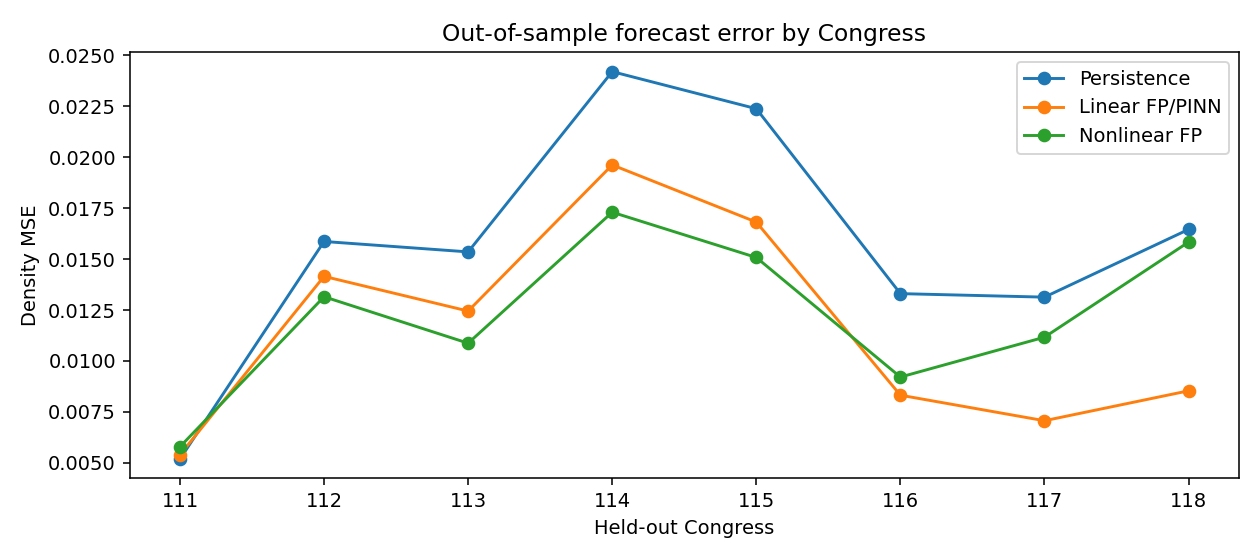

In [ ]:

# Congress-by-Congress OOS error.
plt.figure(figsize=(9, 4))
plt.plot(test_congresses_results, persistence_mse, marker="o", label="Persistence")
plt.plot(test_congresses_results, linear_pinn_mse, marker="o", label="Linear FP/PINN")
plt.plot(test_congresses_results, nonlinear_mse, marker="o", label="Nonlinear FP")

if "vanilla_mse" in globals():
    plt.plot(test_congresses_results, vanilla_mse, marker="o", label="Vanilla FPE")

plt.xlabel("Held-out Congress")
plt.ylabel("Density MSE")
plt.title("Out-of-sample forecast error by Congress")
plt.legend()
plt.tight_layout()
plt.show()


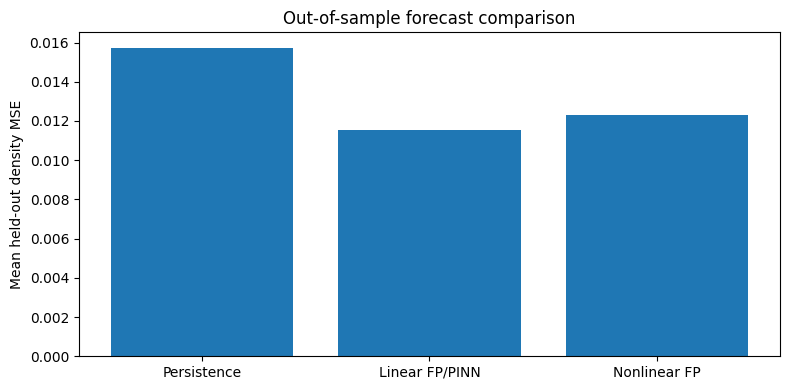

In [ ]:

labels = ["Persistence", "Linear FP/PINN", "Nonlinear FP"]
mean_mse = [
    persistence_mse.mean(),
    linear_pinn_mse.mean(),
    nonlinear_mse.mean(),
]

if "vanilla_mse" in globals():
    labels.insert(1, "Vanilla FPE")
    mean_mse.insert(1, vanilla_mse.mean())

plt.figure(figsize=(8, 4))
plt.bar(labels, mean_mse)
plt.ylabel("Mean held-out density MSE")
plt.title("Mean out-of-sample forecast error")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



# Current takeaway

From the completed full-notebook run:

- **Linear FP/PINN:** mean OOS MSE \(=0.01154\), IAE \(=0.16357\)
- **Nonlinear FP:** mean OOS MSE \(=0.01230\), IAE \(=0.16920\)
- **Persistence:** mean OOS MSE \(=0.01573\), IAE \(=0.18417\)

So both dynamical models beat the no-change benchmark.

- Linear FP/PINN improves MSE by about **26.6%** vs. persistence.
- Nonlinear FP improves MSE by about **21.8%** vs. persistence.
- In the current specification, nonlinear FP is about **6.5% worse in mean MSE** than the simpler Linear FP/PINN.
- However, nonlinear FP has lower MSE than Linear FP/PINN in **4 of the 8** held-out Congresses (112–115).

### Presentation conclusion

The nonlinear formulation successfully introduces a **distribution-dependent drift-generating mechanism**, but the present parameterization has **not yet produced a consistent OOS accuracy gain over the simpler PINN baseline**.

That is the result to present accurately. The next research question is whether better identification / regularization of \(K\), diffusion \(D\), and KDE bandwidth can turn the mechanistic extension into a predictive improvement.
